## LightGBM和CatBoost算法

In [22]:
!pip install lightgbm catboost -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')  # 忽略警告信息，让输出更干净

In [24]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import lightgbm as lgb
from catboost import CatBoostClassifier

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("库导入成功！")
print(f"LightGBM 版本: {lgb.__version__}")
print(f"CatBoost 版本: {CatBoostClassifier.__module__}")

库导入成功！
LightGBM 版本: 4.7.0
CatBoost 版本: catboost.core


### 数据准备

In [25]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print("="*70)
print("数据集信息")
print("="*70)
print(f"样本数量: {X.shape[0]}")
print(f"特征数量: {X.shape[1]}")
print(f"标签分布: 恶性={np.sum(y==0)}, 良性={np.sum(y==1)}")
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"训练集：{X_train.shape}")
print(f"测试集：{X_test.shape}")

数据集信息
样本数量: 569
特征数量: 30
标签分布: 恶性=212, 良性=357
训练集：(455, 30)
测试集：(114, 30)


定义评估函数

In [26]:
def evaluate_classifier(name,y_true,y_pred,y_proba=None,train_time=0):
    """全面评估分类模型"""
    acc=accuracy_score(y_true,y_pred)
    prec=precision_score(y_true,y_pred)
    rec=recall_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)
    auc_val=roc_auc_score(y_true,y_proba[:,1])if y_proba is not None else np.nan
    print(f"{name:<35s}|Acc={acc:.4f}|Prec={prec:.4f}|Rec={rec:.4f}|F1={f1:.4f}|AUC={auc_val:.4f}|Train Time={train_time:.2f}s")
    return{
        'name':name,
        'acc':acc,
        'prec':prec,
        'rec':rec,
        'f1':f1,
        'auc':auc_val,
        'train_time':train_time
    }
all_results=[]


### LightGBM 模型

In [27]:
print("="*70)
print("LightGBM 不同学习率对比")
print("="*70)

lgb_lr_results = []
lr_list = [0.01, 0.05, 0.1, 0.3, 0.5]

for lr in lr_list:
    start = time.time()
    model=lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=lr,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train,y_train)
    lgb_time=time.time()-start
    lgb_pred=model.predict(X_test)
    lgb_proba=model.predict_proba(X_test)
    result=evaluate_classifier(f"LightGBM lr={lr}",y_test,lgb_pred,lgb_proba,lgb_time)
    lgb_lr_results.append(result)
    all_results.append(result)
    print("\n" + "="*70)
print("LightGBM 不同叶子数量对比")
print("="*70)

lgb_leaves_results = []
leaves_list = [7, 15, 31, 63, 127]

for leaves in leaves_list:
    start = time.time()
    
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=leaves,         # 叶节点数量（LightGBM 核心参数）
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(X_train, y_train)
    lgb_time = time.time() - start
    lgb_pred = model.predict(X_test)
    lgb_proba = model.predict_proba(X_test)
    
    result = evaluate_classifier(f"LightGBM(leaves={leaves})", y_test, lgb_pred, lgb_proba, lgb_time)
    result['param'] = leaves
    lgb_leaves_results.append(result)
    all_results.append(result)

LightGBM 不同学习率对比


LightGBM lr=0.01                   |Acc=0.9474|Prec=0.9459|Rec=0.9722|F1=0.9589|AUC=0.9907|Train Time=0.18s

LightGBM lr=0.05                   |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9931|Train Time=0.66s

LightGBM lr=0.1                    |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9914|Train Time=0.17s

LightGBM lr=0.3                    |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9904|Train Time=0.09s

LightGBM lr=0.5                    |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9891|Train Time=0.05s

LightGBM 不同叶子数量对比
LightGBM(leaves=7)                 |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9914|Train Time=0.05s
LightGBM(leaves=15)                |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9911|Train Time=0.09s
LightGBM(leaves=31)                |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9914|Train Time=0.11s
LightGBM(leaves=63)                |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9914|Train Time=0.10s
Light

#### CatBoost

In [29]:
print("\n" + "="*70)
print("CatBoost 不同学习率对比")
print("="*70)

cat_lr_results = []
for lr in lr_list:
    start = time.time()
    
    # 创建 CatBoost 分类器
    model = CatBoostClassifier(
        iterations=100,
        learning_rate=lr,
        depth=6,
        l2_leaf_reg=3.0,
        border_count=128,
        random_state=42,
        verbose=False
    )
    model.fit(X_train,y_train)
    cat_time=time.time()-start
    cat_pred=model.predict(X_test)
    cat_proba=model.predict_proba(X_test)
    result=evaluate_classifier(f"CatBoost lr={lr}",y_test,cat_pred,cat_proba,cat_time)
    result["param"]=lr
    cat_lr_results.append(result)
    all_results.append(result)


CatBoost 不同学习率对比
CatBoost lr=0.01                   |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9954|Train Time=0.65s
CatBoost lr=0.05                   |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9957|Train Time=0.31s
CatBoost lr=0.1                    |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9980|Train Time=0.32s
CatBoost lr=0.3                    |Acc=0.9737|Prec=0.9726|Rec=0.9861|F1=0.9793|AUC=0.9980|Train Time=0.29s
CatBoost lr=0.5                    |Acc=0.9561|Prec=0.9589|Rec=0.9722|F1=0.9655|AUC=0.9934|Train Time=0.35s


In [30]:
print("\n" + "="*70)
print("CatBoost 不同树深度对比")
print("="*70)
cat_depth_results = []
depth_list = [3, 4, 6, 8, 10]

for depth in depth_list:
    start = time.time()
    
    model = CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=depth,               # 树深度（对称树）
        l2_leaf_reg=3.0,
        border_count=128,
        random_seed=42,
        verbose=False
    )
    
    model.fit(X_train, y_train)
    cat_time = time.time() - start
    cat_pred = model.predict(X_test)
    cat_proba = model.predict_proba(X_test)
    
    result = evaluate_classifier(f"CatBoost(depth={depth})", y_test, cat_pred, cat_proba, cat_time)
    result['param'] = depth
    cat_depth_results.append(result)
    all_results.append(result)



CatBoost 不同树深度对比
CatBoost(depth=3)                  |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9950|Train Time=0.21s
CatBoost(depth=4)                  |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9974|Train Time=0.22s
CatBoost(depth=6)                  |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9980|Train Time=0.45s
CatBoost(depth=8)                  |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9954|Train Time=0.97s
CatBoost(depth=10)                 |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9960|Train Time=5.19s


In [31]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*70)
print("四大集成算法横向对比（使用各自较优参数）")
print("="*70)
comparison_models = {}
# 1. 随机森林
start = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_time = time.time() - start
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)
result = evaluate_classifier("随机森林(n=100,d=5)", y_test, rf_pred, rf_proba, rf_time)
comparison_models['随机森林'] = rf
all_results.append(result)

# 2. XGBoost
start = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_time = time.time() - start
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)
result = evaluate_classifier("XGBoost(n=100,d=5)", y_test, xgb_pred, xgb_proba, xgb_time)
comparison_models['XGBoost'] = xgb_model
all_results.append(result)

# 3. LightGBM
start = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.1, num_leaves=31,
    max_depth=-1, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start
lgb_pred = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)
result = evaluate_classifier("LightGBM(leaves=31)", y_test, lgb_pred, lgb_proba, lgb_time)
comparison_models['LightGBM'] = lgb_model
all_results.append(result)

# 4. CatBoost
start = time.time()
cat_model = CatBoostClassifier(
    iterations=100, learning_rate=0.1, depth=6,
    l2_leaf_reg=3.0, border_count=128,
    random_seed=42, verbose=False
)
cat_model.fit(X_train, y_train)
cat_time = time.time() - start
cat_pred = cat_model.predict(X_test)
cat_proba = cat_model.predict_proba(X_test)
result = evaluate_classifier("CatBoost(depth=6)", y_test, cat_pred, cat_proba, cat_time)
comparison_models['CatBoost'] = cat_model
all_results.append(result)


四大集成算法横向对比（使用各自较优参数）
随机森林(n=100,d=5)                    |Acc=0.9561|Prec=0.9589|Rec=0.9722|F1=0.9655|AUC=0.9934|Train Time=0.20s
XGBoost(n=100,d=5)                 |Acc=0.9474|Prec=0.9459|Rec=0.9722|F1=0.9589|AUC=0.9937|Train Time=1.82s
LightGBM(leaves=31)                |Acc=0.9649|Prec=0.9595|Rec=0.9861|F1=0.9726|AUC=0.9914|Train Time=0.13s
CatBoost(depth=6)                  |Acc=0.9561|Prec=0.9467|Rec=0.9861|F1=0.9660|AUC=0.9980|Train Time=0.60s


### 可视化

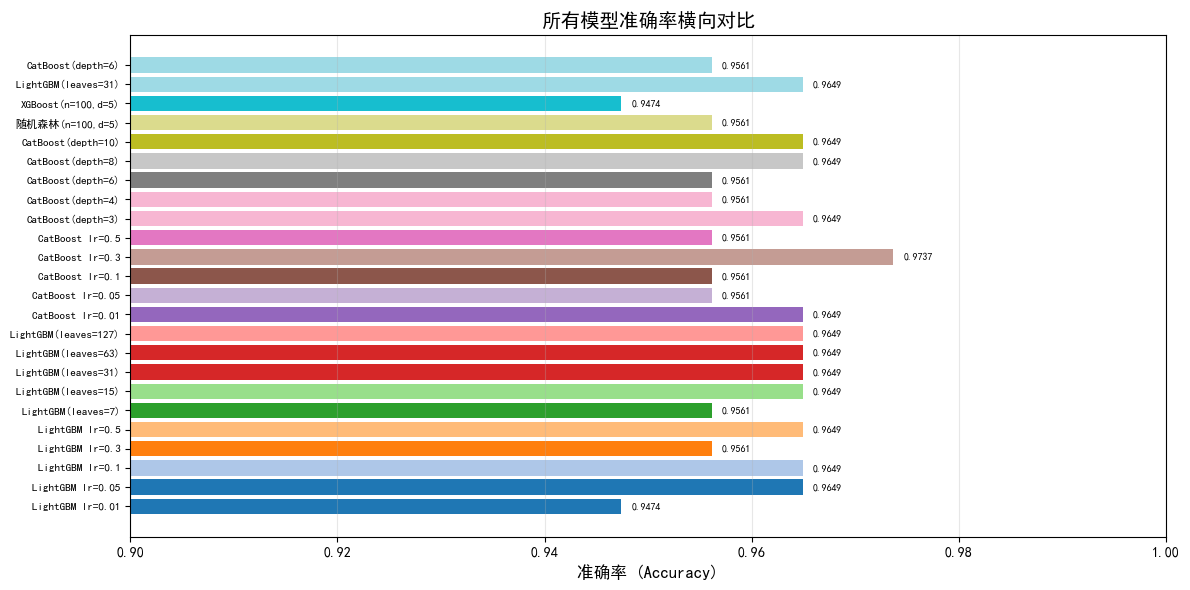

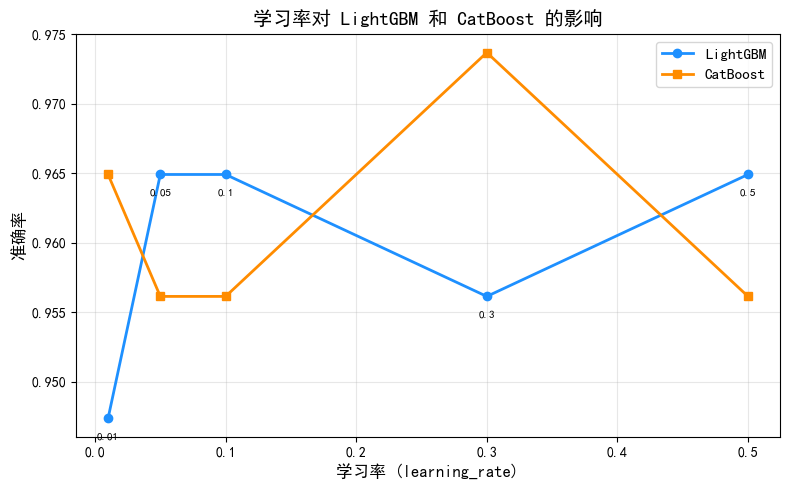

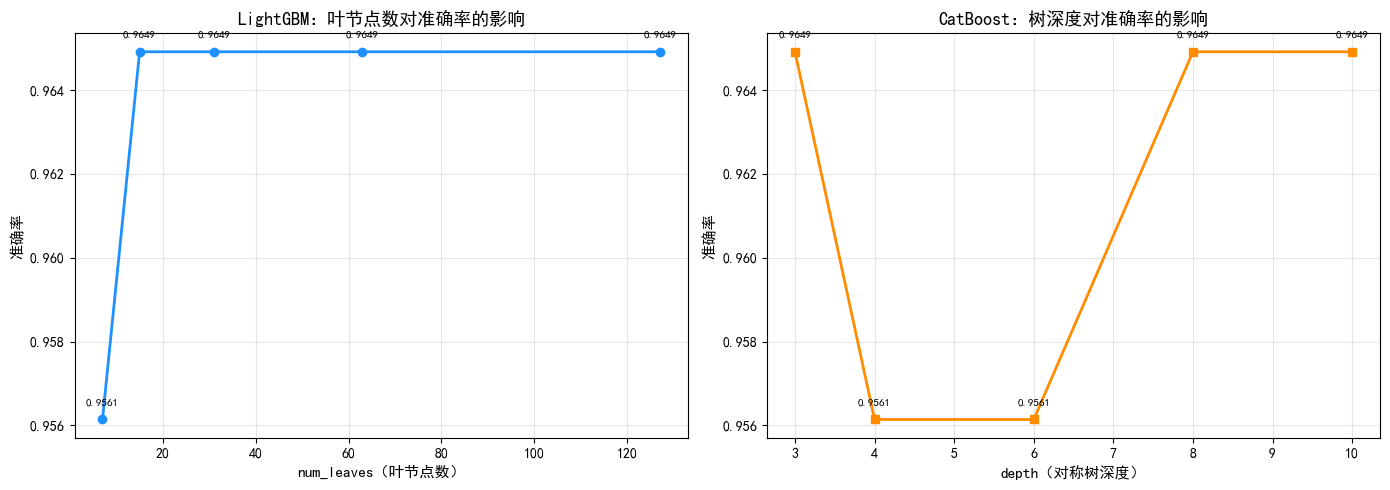

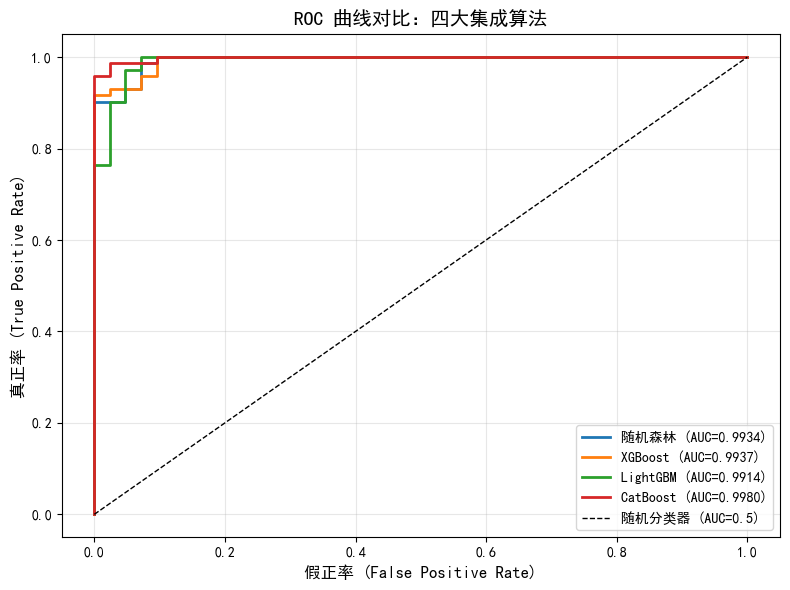

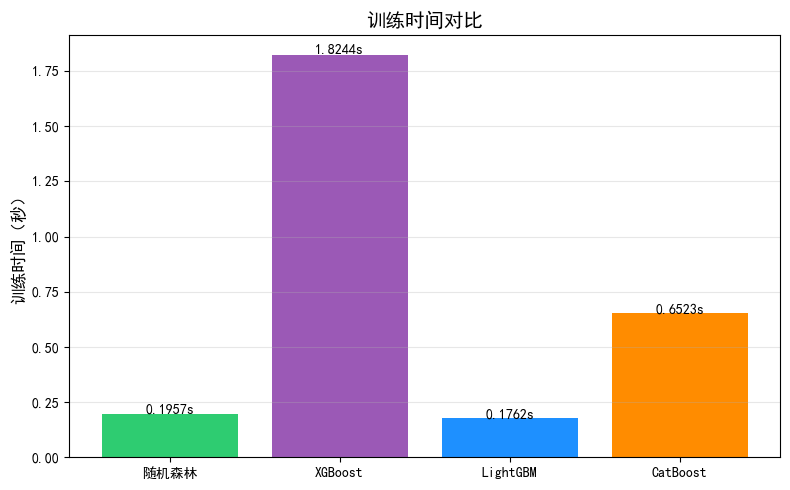

In [34]:
# ==================== 图1：所有模型准确率横向对比 ====================
fig1, ax1 = plt.subplots(figsize=(12, 6))

names_all = [r['name'] for r in all_results]
accs_all = [r['acc'] for r in all_results]
colors_all = plt.cm.tab20(np.linspace(0, 1, len(names_all)))

bars1 = ax1.barh(range(len(names_all)), accs_all, color=colors_all)
ax1.set_yticks(range(len(names_all)))
ax1.set_yticklabels(names_all, fontsize=8)
ax1.set_xlabel('准确率 (Accuracy)', fontsize=12)
ax1.set_title('所有模型准确率横向对比', fontsize=14)
ax1.set_xlim([0.90, 1.0])
for i, (bar, val) in enumerate(zip(bars1, accs_all)):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7)
ax1.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ==================== 图2：学习率对 LightGBM 和 CatBoost 的影响 ====================
fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(lr_list, [r['acc'] for r in lgb_lr_results], marker='o', linewidth=2,
         label='LightGBM', color='#1E90FF')
ax2.plot(lr_list, [r['acc'] for r in cat_lr_results], marker='s', linewidth=2,
         label='CatBoost', color='#FF8C00')
ax2.set_xlabel('学习率 (learning_rate)', fontsize=12)
ax2.set_ylabel('准确率', fontsize=12)
ax2.set_title('学习率对 LightGBM 和 CatBoost 的影响', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
for i, lr in enumerate(lr_list):
    ax2.annotate(f"{lr}", (lr, [r['acc'] for r in lgb_lr_results][i]),
                 textcoords="offset points", xytext=(0, -15), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# ==================== 图3：树复杂度参数对比 ====================
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))

# LightGBM num_leaves
ax3a.plot(leaves_list, [r['acc'] for r in lgb_leaves_results], marker='o', linewidth=2, color='#1E90FF')
ax3a.set_xlabel('num_leaves（叶节点数）', fontsize=11)
ax3a.set_ylabel('准确率', fontsize=11)
ax3a.set_title('LightGBM：叶节点数对准确率的影响', fontsize=13)
ax3a.grid(True, alpha=0.3)
for i, leaves in enumerate(leaves_list):
    ax3a.annotate(f"{[r['acc'] for r in lgb_leaves_results][i]:.4f}", 
                  (leaves, [r['acc'] for r in lgb_leaves_results][i]),
                  textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

# CatBoost depth
ax3b.plot(depth_list, [r['acc'] for r in cat_depth_results], marker='s', linewidth=2, color='#FF8C00')
ax3b.set_xlabel('depth（对称树深度）', fontsize=11)
ax3b.set_ylabel('准确率', fontsize=11)
ax3b.set_title('CatBoost：树深度对准确率的影响', fontsize=13)
ax3b.grid(True, alpha=0.3)
for i, depth in enumerate(depth_list):
    ax3b.annotate(f"{[r['acc'] for r in cat_depth_results][i]:.4f}",
                  (depth, [r['acc'] for r in cat_depth_results][i]),
                  textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# ==================== 图4：ROC 曲线对比 ====================
fig4, ax4 = plt.subplots(figsize=(8, 6))

for name, model in comparison_models.items():
    if name == '随机森林':
        y_proba = model.predict_proba(X_test)[:, 1]
    elif name == 'XGBoost':
        y_proba = model.predict_proba(X_test)[:, 1]
    elif name == 'LightGBM':
        y_proba = model.predict_proba(X_test)[:, 1]
    elif name == 'CatBoost':
        y_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)
    ax4.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')

ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机分类器 (AUC=0.5)')
ax4.set_xlabel('假正率 (False Positive Rate)', fontsize=12)
ax4.set_ylabel('真正率 (True Positive Rate)', fontsize=12)
ax4.set_title('ROC 曲线对比：四大集成算法', fontsize=14)
ax4.legend(loc='lower right', fontsize=10)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==================== 图5：训练时间对比 ====================
fig5, ax5 = plt.subplots(figsize=(8, 5))

compare_names = ['随机森林', 'XGBoost', 'LightGBM', 'CatBoost']
compare_times = []
for n in compare_names:
    for r in all_results:
        if r['name'].startswith(n):
            compare_times.append(r['train_time'])
            break

bars5 = ax5.bar(compare_names, compare_times, color=['#2ECC71', '#9B59B6', '#1E90FF', '#FF8C00'])
ax5.set_ylabel('训练时间（秒）', fontsize=12)
ax5.set_title('训练时间对比', fontsize=14)
for bar, t in zip(bars5, compare_times):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{t:.4f}s', ha='center', fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

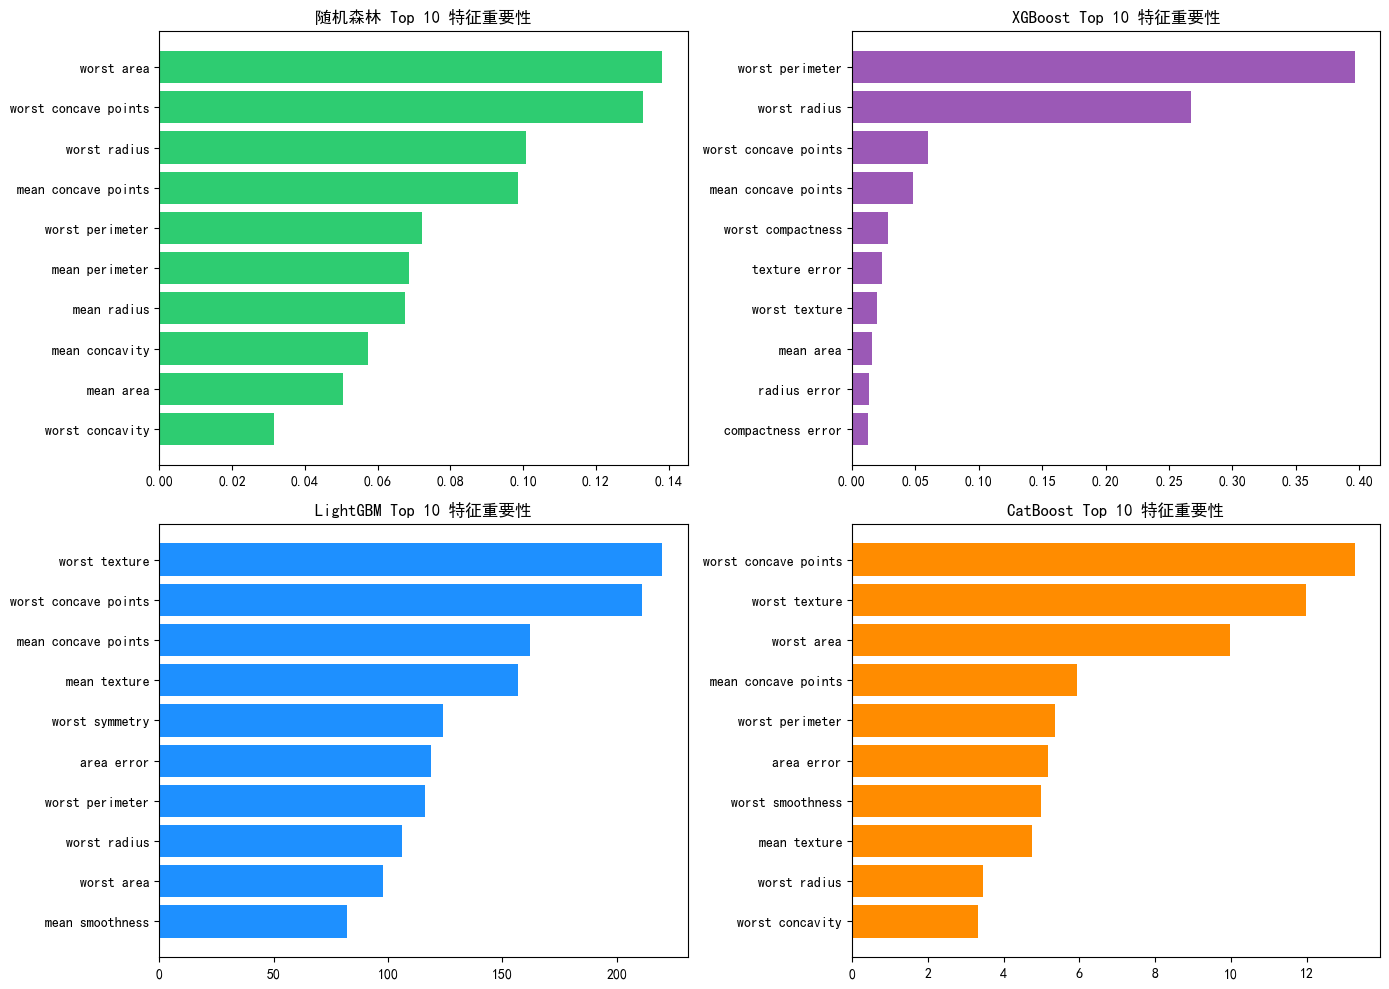

In [33]:
# ==================== 特征重要性对比 ====================
fig6, axes6 = plt.subplots(2, 2, figsize=(14, 10))

# 随机森林特征重要性
rf_importance = comparison_models['随机森林'].feature_importances_
rf_imp_df = pd.DataFrame({'feature': feature_names, 'importance': rf_importance}).sort_values('importance', ascending=True).tail(10)
axes6[0, 0].barh(rf_imp_df['feature'], rf_imp_df['importance'], color='#2ECC71')
axes6[0, 0].set_title('随机森林 Top 10 特征重要性', fontsize=12)

# XGBoost 特征重要性
xgb_importance = comparison_models['XGBoost'].feature_importances_
xgb_imp_df = pd.DataFrame({'feature': feature_names, 'importance': xgb_importance}).sort_values('importance', ascending=True).tail(10)
axes6[0, 1].barh(xgb_imp_df['feature'], xgb_imp_df['importance'], color='#9B59B6')
axes6[0, 1].set_title('XGBoost Top 10 特征重要性', fontsize=12)

# LightGBM 特征重要性
lgb_importance = comparison_models['LightGBM'].feature_importances_
lgb_imp_df = pd.DataFrame({'feature': feature_names, 'importance': lgb_importance}).sort_values('importance', ascending=True).tail(10)
axes6[1, 0].barh(lgb_imp_df['feature'], lgb_imp_df['importance'], color='#1E90FF')
axes6[1, 0].set_title('LightGBM Top 10 特征重要性', fontsize=12)

# CatBoost 特征重要性
cat_importance = comparison_models['CatBoost'].get_feature_importance()
cat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': cat_importance}).sort_values('importance', ascending=True).tail(10)
axes6[1, 1].barh(cat_imp_df['feature'], cat_imp_df['importance'], color='#FF8C00')
axes6[1, 1].set_title('CatBoost Top 10 特征重要性', fontsize=12)

plt.tight_layout()
plt.show()